In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [2]:
from data_parser import clean_df, get_group_prices
from research_tools import get_options_df, implied_vol_bisection
import pandas as pd
import matplotlib.pyplot as plt
df=get_group_prices(["./data/options_past_data/prices_round_3_day_0.csv"])

In [3]:
df.head(5)

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,0,VOLCANIC_ROCK_VOUCHER_10500,99,19,0,0,0,0,100,19,0,0,0,0,99.5,0.0
1,1,0,0,DJEMBES,13493,72,0,0,0,0,13494,72,0,0,0,0,13493.5,0.0
2,2,0,0,CROISSANTS,4321,111,0,0,0,0,4322,111,0,0,0,0,4321.5,0.0
3,3,0,0,JAMS,6631,210,0,0,0,0,6633,210,0,0,0,0,6632.0,0.0
4,4,0,0,VOLCANIC_ROCK_VOUCHER_10000,505,19,0,0,0,0,506,19,0,0,0,0,505.5,0.0


In [3]:
vouchers = ['VOLCANIC_ROCK_VOUCHER_10500', 'VOLCANIC_ROCK_VOUCHER_10000', 
            'VOLCANIC_ROCK_VOUCHER_9750', 'VOLCANIC_ROCK_VOUCHER_9500',
            'VOLCANIC_ROCK_VOUCHER_10250']
odf=get_options_df(df, 8, "VOLCANIC_ROCK", vouchers)

In [4]:
moneyness=np.log((odf["strike"].to_numpy()/odf["spot_price"].to_numpy())) / np.sqrt(odf["time_to_expiry"])
iv_array = odf["implied_volatility"].to_numpy()

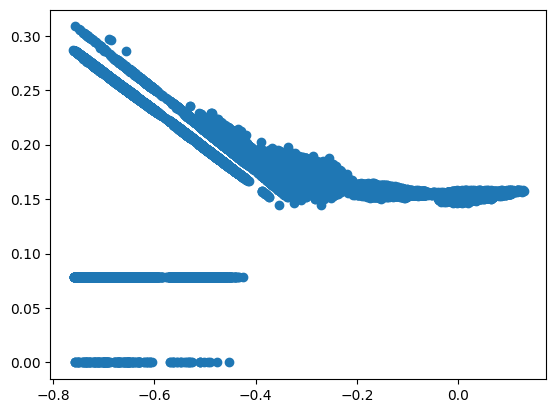

In [5]:
import matplotlib.pyplot as plt
plt.scatter(moneyness, iv_array)

In [21]:
# Take outliers
def filter_outliers(moneyness_arr, implied_vols):
    m_result, vol_result = [], []
    for i in range(len(implied_vols)):
        if implied_vols[i] > 0.1:
            m_result.append(moneyness_arr[i])
            vol_result.append(implied_vols[i])
    return (np.array(m_result), np.array(vol_result))

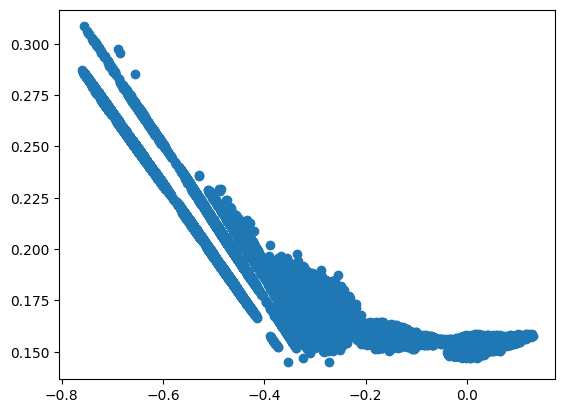

In [23]:
import matplotlib.pyplot as plt
new_moneyness, new_iv = filter_outliers(moneyness, iv_array)
plt.scatter(new_moneyness, new_iv)

In [46]:
# Fitting the smoooth IV curve

coeffs = np.polyfit(new_moneyness, new_iv, 2)
c=coeffs[2]
b=coeffs[1]
a=coeffs[0]
model = np.poly1d(coeffs)

In [49]:
# sample func for model
def calc_smooth_iv(calc_moneyness):
    a=0.26111097548467427
    b=0.022738417966209856
    c=0.1528342507405559
    return a * calc_moneyness**2 + b * calc_moneyness + c 

In [50]:
calc_smooth_iv(-0.2)

0.1587310061667009

In [47]:
# Print Parameters
print("a: " + str(a))
print("b: " + str(b))
print("c: " + str(c))

a: 0.26111097548467427
b: 0.022738417966209856
c: 0.1528342507405559


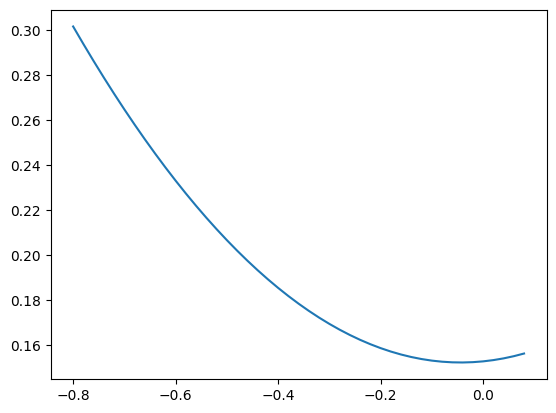

In [43]:
res = []
x=[]
m=-0.8
while (m<=0.1):
    x.append(m)
    res.append(model(m))
    m+=0.02
plt.plot(x,res)

In [45]:
prices_files = []
trades_files = []
round = 3
for i in range(0, 1):
    prices_files.append("./data/options_past_data/prices_round_"+str(round)+"_day_"+str(i)+".csv")
    trades_files.append("./data/options_past_data/trades_round_"+str(round)+"_day_"+str(i)+".csv")
backtesting_engine = Backtester(prices_files, trades_files)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project